In [5]:
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import meteostat as ms

# Load data

In [65]:
# 1) Choose station (near downtown LA). You can replace coords or fetch another station.
POINT = ms.Point(34.05, -118.24)  # Try with your location
stations = ms.stations.nearby(POINT, limit=20)  # Downtown Los Angeles coords

# 2) Define target weeks (inclusive)
p1_start, p1_end = datetime(2016,12,12), datetime(2016,12,19)
p2_start, p2_end = datetime(2016,8,12),  datetime(2016,8,19)

In [66]:
# find closest station with data in both target weeks
def check_station_data(st_id, start, end, min_days=1, vars=['temp','wspd']):
    """Check station data availability in a date window. Returns dict and prints summary."""
    try:
        ts = ms.daily(st_id, start, end).fetch()
    except Exception as e:
        print(f"{st_id}: error fetching -> {e}")
        return {'id': st_id, 'has_data': False, 'error': str(e)}

    if ts is None or ts.empty:
        print(f"✗ Station {st_id} has NO data in Meteostat for {start}–{end}")
        return {'id': st_id, 'has_data': False, 'records': 0}

    # count days where any requested var is present
    valid_days = ts[vars].notna().any(axis=1).sum()
    print(f"✓ Station {st_id} HAS data: records={len(ts)}, valid_days={valid_days}, range={ts.index.min()} to {ts.index.max()}")
    return {'id': st_id, 'has_data': int(valid_days) >= min_days, 'records': len(ts),
            'valid_days': int(valid_days), 'range': (ts.index.min(), ts.index.max())}

chosen = None
for st in stations.index:
    r1 = check_station_data(st, p1_start, p1_end, min_days=4)
    r2 = check_station_data(st, p2_start, p2_end, min_days=4)
    if r1.get('has_data') and r2.get('has_data'):
        chosen = st
        break

if chosen:
    print("Chosen station with data in both windows:", chosen)
else:
    print("No nearby station (limit=10) had >=4 valid days in both windows.")

✗ Station KCQT0 has NO data in Meteostat for 2016-12-12 00:00:00–2016-12-19 00:00:00
✗ Station KCQT0 has NO data in Meteostat for 2016-08-12 00:00:00–2016-08-19 00:00:00
✓ Station KHHR0 HAS data: records=8, valid_days=8, range=2016-12-12 00:00:00 to 2016-12-19 00:00:00
✓ Station KHHR0 HAS data: records=8, valid_days=8, range=2016-08-12 00:00:00 to 2016-08-19 00:00:00
Chosen station with data in both windows: KHHR0


In [70]:
print("\nNearby stations data summary:")
results = []
for st in stations.index[:10]:
    r1 = check_station_data(st, p1_start, p1_end, min_days=4)
    r2 = check_station_data(st, p2_start, p2_end, min_days=4)

    r1_range = r1.get('range')
    r2_range = r2.get('range')

    results.append({
        'id': st,
        'p1_has': bool(r1.get('has_data')),
        'p1_valid_days': int(r1.get('valid_days', 0)),
        'p1_records': int(r1.get('records', 0)),
        'p1_start_avail': str(r1_range[0]) if r1_range else None,
        'p1_end_avail':   str(r1_range[1]) if r1_range else None,
        'p2_has': bool(r2.get('has_data')),
        'p2_valid_days': int(r2.get('valid_days', 0)),
        'p2_records': int(r2.get('records', 0)),
        'p2_start_avail': str(r2_range[0]) if r2_range else None,
        'p2_end_avail':   str(r2_range[1]) if r2_range else None,
    })

summary = pd.DataFrame(results).set_index('id')
print("\nNearby stations summary (top 10):")
print(summary)

candidates = summary[(summary.p1_has) & (summary.p2_has)]
if not candidates.empty:
    chosen = candidates.index[0]
    print("\nChosen station with data in both windows:", chosen)
    if chosen in stations.index:
        print(stations.loc[chosen])
else:
    print("\nNo nearby station (top 10) had >=4 valid days in both windows.")


Nearby stations data summary:
✗ Station KCQT0 has NO data in Meteostat for 2016-12-12 00:00:00–2016-12-19 00:00:00
✗ Station KCQT0 has NO data in Meteostat for 2016-08-12 00:00:00–2016-08-19 00:00:00
✓ Station KHHR0 HAS data: records=8, valid_days=8, range=2016-12-12 00:00:00 to 2016-12-19 00:00:00
✓ Station KHHR0 HAS data: records=8, valid_days=8, range=2016-08-12 00:00:00 to 2016-08-19 00:00:00
✓ Station 72295 HAS data: records=8, valid_days=8, range=2016-12-12 00:00:00 to 2016-12-19 00:00:00
✓ Station 72295 HAS data: records=8, valid_days=8, range=2016-08-12 00:00:00 to 2016-08-19 00:00:00
✗ Station KEMT0 has NO data in Meteostat for 2016-12-12 00:00:00–2016-12-19 00:00:00
✗ Station KEMT0 has NO data in Meteostat for 2016-08-12 00:00:00–2016-08-19 00:00:00
✗ Station 71D38 has NO data in Meteostat for 2016-12-12 00:00:00–2016-12-19 00:00:00
✗ Station 71D38 has NO data in Meteostat for 2016-08-12 00:00:00–2016-08-19 00:00:00
✓ Station 72288 HAS data: records=8, valid_days=8, range=20

In [71]:
def station_data_range(station_id_or_obj, start=datetime(1900,1,1), end=None):
    """Return {'id', 'min', 'max', 'records'} for a station (or error info)."""
    if end is None:
        end = datetime.now()
    try:
        df = ms.daily(station_id_or_obj, start, end).fetch()
    except Exception as e:
        return {'id': station_id_or_obj, 'error': str(e)}
    if df is None or df.empty:
        return {'id': station_id_or_obj, 'min': None, 'max': None, 'records': 0}
    return {
        'id': station_id_or_obj,
        'min': str(df.index.min().date()),
        'max': str(df.index.max().date()),
        'records': len(df)
    }

# Example usage:
print(station_data_range("KCQT0"))
# For multiple nearby stations:
stations_df = ms.stations.nearby(ms.Point(34.05, -118.24), limit=10).fetch()
ranges = [station_data_range(st) for st in stations_df.index]
print(pd.DataFrame(ranges).set_index('id'))

{'id': 'KCQT0', 'error': 'Daily requests longer than 30 years are blocked by default. To enable large requests, set `config.block_large_requests = False`.'}


AttributeError: 'DataFrame' object has no attribute 'fetch'

In [69]:
# Identify LAX ID 

# LAX coordinates (Los Angeles International)
POINT = ms.Point(33.9416, -118.4085)
ms.stations.nearby(POINT, limit=10)

,name,country,region,latitude,longitude,elevation,timezone,distance
id,,,,,,,,
72295,Los Angeles Airport,US,CA,33.93330,-118.38330,38,America/Los_Angeles,2501.3
KHHR0,Hawthorne / Cypave,US,CA,33.92280,-118.33520,20,America/Los_Angeles,7078.3
71D38,Santa Monica Municipal Airport,US,CA,34.01583,-118.45139,53,America/Los_Angeles,9152.5
KCQT0,Los Angeles / Jefferson,US,CA,34.01670,-118.28330,56,America/Los_Angeles,14248.1
KTOA0,Torrance / Walteria,US,CA,33.80340,-118.33960,31,America/Los_Angeles,16631.7
72297,Long Beach Airport,US,CA,33.81670,-118.15000,17,America/Los_Angeles,27610.8
72288,Burbank-Glendale-Pasadena,US,CA,34.20000,-118.36670,236,America/Los_Angeles,28989.6
KVNY0,Van Nuys / Raymer,US,CA,34.20980,-118.49000,245,America/Los_Angeles,30752.6
KWHP0,Los Angeles / Pacoima,US,CA,34.25930,-118.41340,306,America/Los_Angeles,35329.5


In [76]:
ms.config.block_large_requests = False

def monthly_range(station_id, start=datetime(1900,1,1), end=None):
    end = end or datetime.now()
    try:
        df = ms.monthly(station_id, start, end).fetch()
        return str(df.index.min().date()), str(df.index.max().date())
    except Exception:
        return None, None

print(monthly_range("72295"))

('1944-01-01', '2025-11-01')


Fetching hourly data for LAX (2010-2015)...
Total records: 52559, Winter records: 12961

Hourly cycle (first few rows):
   hour       mean   p25   p75  count
0     0  16.489649  14.4  18.3    541
1     1   15.64963  13.9  17.2    540
2     2  14.979444  13.3  16.1    540
3     3  14.723148  13.3  16.1    540
4     4  14.568704  12.8  16.1    540


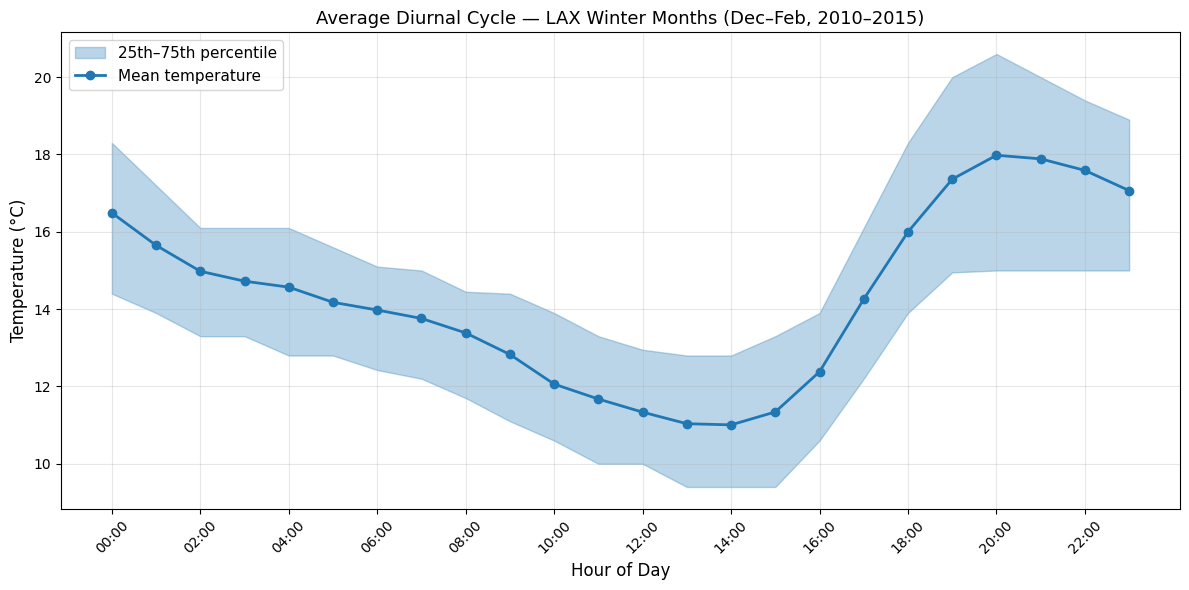

In [77]:
# LAX Climatology (2010-2015), Winter

st_id = "72295"  # LAX

# 1) Fetch hourly data for the full period (2010-2015)
start = datetime(2010, 1, 1)
end = datetime(2015, 12, 31)

print("Fetching hourly data for LAX (2010-2015)...")
ts = ms.hourly(st_id, start, end).fetch()

# 2) Filter for winter months (Dec, Jan, Feb)
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()

print(f"Total records: {len(ts)}, Winter records: {len(winter_data)}")

# 3) Extract hour of day and group by it
winter_data['hour'] = winter_data.index.hour
hourly_cycle = winter_data.groupby('hour')['temp'].agg([
    'mean',
    ('p25', lambda x: x.quantile(0.25)),
    ('p75', lambda x: x.quantile(0.75)),
    'count'
]).reset_index()

print("\nHourly cycle (first few rows):")
print(hourly_cycle.head())

# 4) Plot with shaded percentile bands
fig, ax = plt.subplots(figsize=(12, 6))

hours = hourly_cycle['hour'].values
mean_temp = hourly_cycle['mean'].values
p25 = hourly_cycle['p25'].values
p75 = hourly_cycle['p75'].values

# Shaded region for 25th-75th percentile
ax.fill_between(hours, p25, p75, alpha=0.3, color='C0', label='25th–75th percentile')

# Mean line
ax.plot(hours, mean_temp, 'o-', linewidth=2, markersize=6, 
        color='C0', label='Mean temperature')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Average Diurnal Cycle — LAX Winter Months (Dec–Feb, 2010–2015)', fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Fetching hourly data for LAX (1995-2015)...
Fetching hourly data for P1 week (Dec 10-19, 2016)...


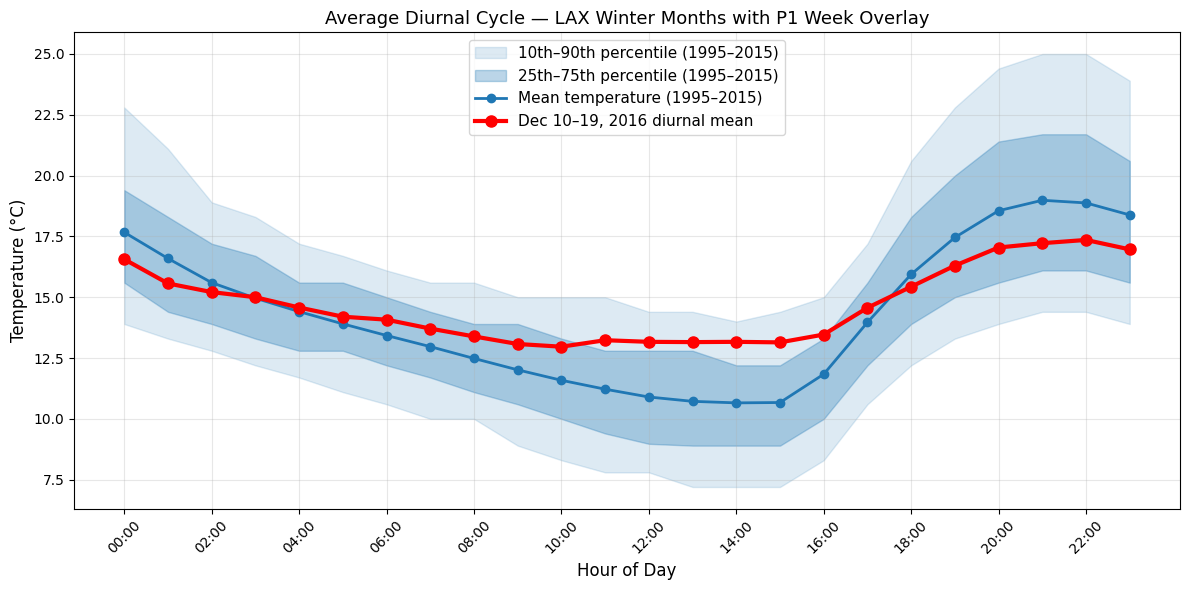

In [115]:
# LAX Climatology (1995-2015), Winter + P1 week overlay

st_id = "KHHR0"  # LAX
start = datetime(1995, 1, 1)
end = datetime(2015, 12, 31)
p1_start, p1_end = datetime(2016, 12, 10), datetime(2016, 12, 19)

# Fetch and prepare climatology data
print("Fetching hourly data for LAX (1995-2015)...")
ts = ms.hourly(st_id, start, end).fetch()
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()
winter_data['hour'] = winter_data.index.hour
hourly_cycle = winter_data.groupby('hour')['temp'].agg([
        'mean',
        ('p10', lambda x: x.quantile(0.10)),
        ('p25', lambda x: x.quantile(0.25)),
        ('p75', lambda x: x.quantile(0.75)),
        ('p90', lambda x: x.quantile(0.90)),
]).reset_index()

# Fetch P1 week data
print("Fetching hourly data for P1 week (Dec 10-19, 2016)...")
ts_p1 = ms.hourly(st_id, p1_start, p1_end).fetch()
ts_p1['hour'] = ts_p1.index.hour
p1_hourly = ts_p1.groupby('hour')['temp'].mean()

# Create combined plot
fig, ax = plt.subplots(figsize=(12, 6))

hours = hourly_cycle['hour'].values
mean_temp = hourly_cycle['mean'].values
p10 = hourly_cycle['p10'].values
p25 = hourly_cycle['p25'].values
p75 = hourly_cycle['p75'].values
p90 = hourly_cycle['p90'].values

# Outer band: 10th-90th percentile (lighter)
ax.fill_between(hours, p10, p90, alpha=0.15, color='C0', label='10th–90th percentile (1995–2015)')

# Inner band: 25th-75th percentile (darker)
ax.fill_between(hours, p25, p75, alpha=0.30, color='C0', label='25th–75th percentile (1995–2015)')

# Mean line (no error bars)
ax.plot(hours, mean_temp, 'o-', linewidth=2, markersize=6, color='C0', label='Mean temperature (1995–2015)')

# P1 week overlay
ax.plot(p1_hourly.index, p1_hourly.values, 'o-', linewidth=3, markersize=8, 
        color='red', label='Dec 10–19, 2016 diurnal mean')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Average Diurnal Cycle — LAX Winter Months with P1 Week Overlay', fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [102]:
# Check data quality for wind speed
st_id = "72295"
start = datetime(2010, 1, 1)
end = datetime(2015, 12, 31)

ts = ms.hourly(st_id, start, end).fetch()
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()
winter_data['hour'] = winter_data.index.hour

# Detailed hourly diagnostics
print("Hourly wind speed data quality:")
for hour in range(24):
    hour_data = winter_data[winter_data['hour'] == hour]['wspd']
    valid_count = hour_data.notna().sum()
    null_count = hour_data.isna().sum()
    min_val = hour_data.min()
    p25 = hour_data.quantile(0.25)
    median = hour_data.median()
    
    print(f"Hour {hour:02d}:00 | Valid: {valid_count:5d} | NaN: {null_count:5d} | Min: {min_val:6.2f} | P25: {p25:6.2f} | Median: {median:6.2f}")

Hourly wind speed data quality:
Hour 00:00 | Valid:   540 | NaN:     1 | Min:   0.00 | P25:  13.00 | Median:  14.80
Hour 01:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:  11.20 | Median:  13.00
Hour 02:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:   9.40 | Median:  11.20
Hour 03:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:   5.40 | Median:   9.40
Hour 04:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:   5.40 | Median:   7.60
Hour 05:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:   0.00 | Median:   7.60
Hour 06:00 | Valid:   509 | NaN:    31 | Min:   0.00 | P25:   0.00 | Median:   7.60
Hour 07:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:   0.00 | Median:   7.60
Hour 08:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:   0.00 | Median:   7.60
Hour 09:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:   0.00 | Median:   7.60
Hour 10:00 | Valid:   540 | NaN:     0 | Min:   0.00 | P25:   0.00 | Median:   5.40
Hour 11:00 | Valid:   540 | NaN:     0 | Min

Fetching hourly data for LAX (1995-2015)...

Hourly cycle statistics:
    hour       mean   p10   p25   p75   p90  count_valid
0      0  16.951611   9.4  13.0  20.5  24.1         1893
1      1  15.230095   7.6  11.2  18.4  24.1         1894
2      2  13.208184   5.4   9.4  16.6  20.5         1894
3      3  11.304065   0.0   7.6  14.8  20.5         1894
4      4   9.828511   0.0   5.4  13.0  18.7         1894
5      5   8.981521   0.0   5.4  13.0  16.6         1894
6      6   8.642803   0.0   5.4  11.2  16.6         1841
7      7   8.816051   0.0   5.4  11.2  16.6         1894
8      8    8.62207   0.0   5.4  11.2  16.6         1894
9      9   8.321553   0.0   5.4  11.2  14.8         1893
10    10   7.476545   0.0   0.0  11.2  14.8         1893
11    11    7.32207   0.0   0.0   9.4  14.8         1894
12    12   7.104083   0.0   0.0   9.4  14.8         1886
13    13     7.0849   0.0   0.0   9.4  14.8         1894
14    14   7.241922   0.0   0.0   9.4  14.8         1894
15    15    8.1703

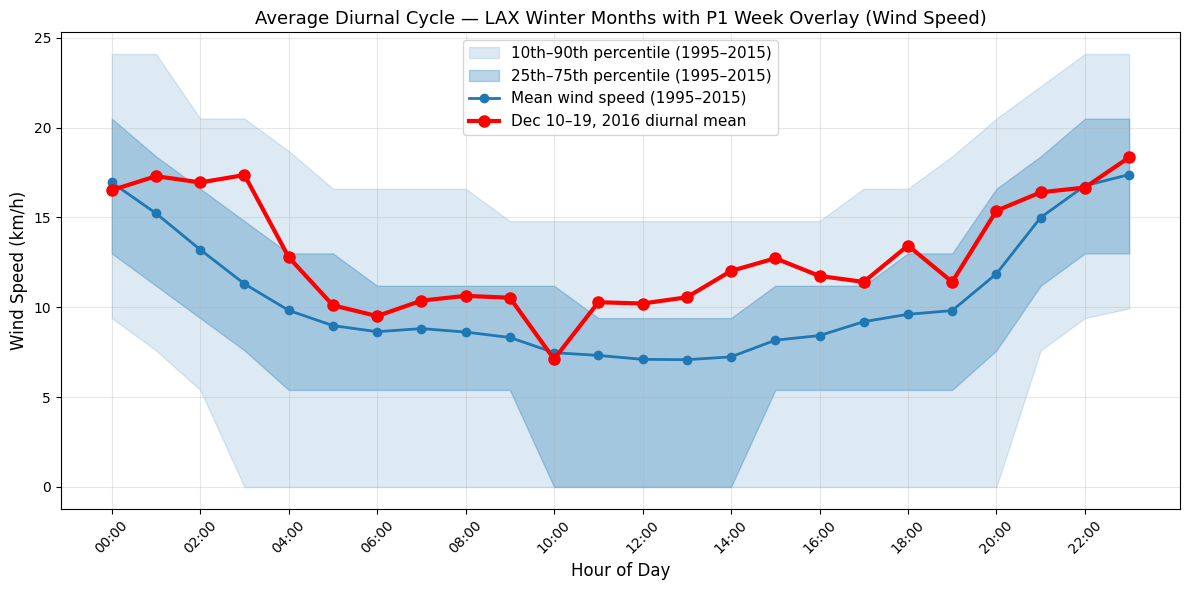

In [113]:
# LAX Climatology (1995-2015), Winter + P1 week overlay — Wind Speed (with 10th/90th percentiles)

st_id = "72295"  # LAX
start = datetime(1995, 1, 1)
end = datetime(2015, 12, 31)
p1_start, p1_end = datetime(2016, 12, 10), datetime(2016, 12, 19)

# Fetch and prepare climatology data
print("Fetching hourly data for LAX (1995-2015)...")
ts = ms.hourly(st_id, start, end).fetch()
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()
winter_data['hour'] = winter_data.index.hour

# Exclude zero wind speeds
# winter_data_nonzero = winter_data[winter_data['wspd'] > 0].copy()

hourly_cycle = winter_data.groupby('hour')['wspd'].agg([
    'mean',
    ('p10', lambda x: x.quantile(0.10)),
    ('p25', lambda x: x.quantile(0.25)),
    ('p75', lambda x: x.quantile(0.75)),
    ('p90', lambda x: x.quantile(0.90)),
    ('count_valid', lambda x: x.notna().sum())
]).reset_index()

print("\nHourly cycle statistics:")
print(hourly_cycle[['hour', 'mean', 'p10', 'p25', 'p75', 'p90', 'count_valid']])

# Fetch P1 week data
print("Fetching hourly data for P1 week (Dec 10-19, 2016)...")
ts_p1 = ms.hourly(st_id, p1_start, p1_end).fetch()
ts_p1['hour'] = ts_p1.index.hour
p1_hourly = ts_p1[ts_p1['wspd'] > 0].groupby('hour')['wspd'].mean()

# Create combined plot
fig, ax = plt.subplots(figsize=(12, 6))

hours = hourly_cycle['hour'].values
mean_wspd = hourly_cycle['mean'].values
p10 = hourly_cycle['p10'].values
p25 = hourly_cycle['p25'].values
p75 = hourly_cycle['p75'].values
p90 = hourly_cycle['p90'].values

# Outer band: 10th-90th percentile (lighter)
ax.fill_between(hours, p10, p90, alpha=0.15, color='C0', label='10th–90th percentile (1995–2015)')

# Inner band: 25th-75th percentile (darker)
ax.fill_between(hours, p25, p75, alpha=0.30, color='C0', label='25th–75th percentile (1995–2015)')

# Mean line
ax.plot(hours, mean_wspd, 'o-', linewidth=2, markersize=6, 
        color='C0', label='Mean wind speed (1995–2015)')

# P1 week overlay
ax.plot(p1_hourly.index, p1_hourly.values, 'o-', linewidth=3, markersize=8, 
        color='red', label='Dec 10–19, 2016 diurnal mean')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
ax.set_title('Average Diurnal Cycle — LAX Winter Months with P1 Week Overlay (Wind Speed)', fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Fetching hourly data for LAX (Dec 2016)...

Hourly cycle statistics (Dec 2016):
    hour       mean    p10   p25    p75    p90  count_valid
0      0  17.767742   11.2  13.0  19.45   25.9           31
1      1  15.386667   7.38  11.2   16.6  22.84           30
2      2  13.516667    7.6  9.85  16.15  20.68           30
3      3  13.076667    7.6   7.6   14.8  17.17           30
4      4  11.033333    5.4   7.6   13.0   18.4           30
5      5       8.11    0.0   5.4  12.55  14.98           30
6      6   8.046667    0.0   7.6    9.4   13.0           30
7      7   8.553333    0.0   5.4   11.2  14.98           30
8      8   9.393333   4.86   5.4   11.2  16.78           30
9      9   8.673333    0.0   5.4  12.55   14.8           30
10    10   8.566667   4.86   5.4    7.6  13.18           30
11    11   8.586667    0.0   5.4   11.2  14.98           30
12    12   9.406667    5.4   5.4   11.2  15.16           30
13    13   7.916667    0.0   5.4    9.4  13.54           30
14    14   8.706667 

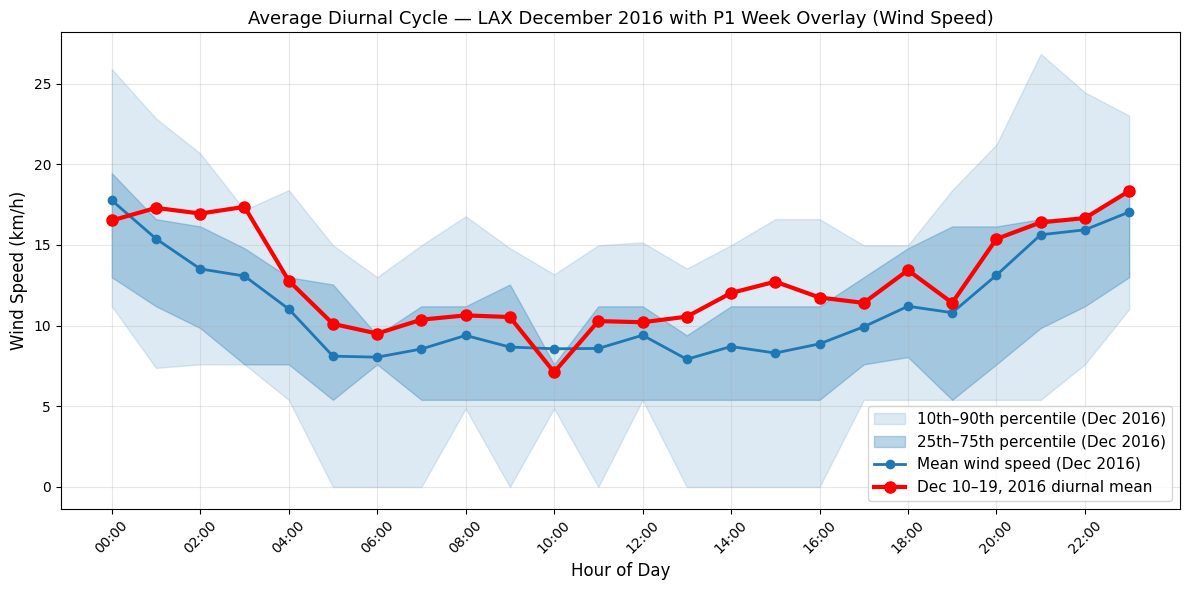

In [112]:
# LAX Climatology (December 2016), Week comparison — Wind Speed

st_id = "72295"  # LAX
month_start = datetime(2016, 12, 1)
month_end = datetime(2016, 12, 31)
p1_start, p1_end = datetime(2016, 12, 10), datetime(2016, 12, 19)

# Fetch and prepare climatology data for the full month
print("Fetching hourly data for LAX (Dec 2016)...")
ts = ms.hourly(st_id, month_start, month_end).fetch()
ts['hour'] = ts.index.hour

# Exclude zero wind speeds
# winter_data_nonzero = ts[ts['wspd'] > 0].copy()

hourly_cycle = ts.groupby('hour')['wspd'].agg([
    'mean',
    ('p10', lambda x: x.quantile(0.10)),
    ('p25', lambda x: x.quantile(0.25)),
    ('p75', lambda x: x.quantile(0.75)),
    ('p90', lambda x: x.quantile(0.90)),
    ('count_valid', lambda x: x.notna().sum())
]).reset_index()

print("\nHourly cycle statistics (Dec 2016):")
print(hourly_cycle[['hour', 'mean', 'p10', 'p25', 'p75', 'p90', 'count_valid']])

# Fetch P1 week data
print("Fetching hourly data for P1 week (Dec 10-19, 2016)...")
ts_p1 = ms.hourly(st_id, p1_start, p1_end).fetch()
ts_p1['hour'] = ts_p1.index.hour
p1_hourly = ts_p1[ts_p1['wspd'] > 0].groupby('hour')['wspd'].mean()

# Create combined plot
fig, ax = plt.subplots(figsize=(12, 6))

hours = hourly_cycle['hour'].values
mean_wspd = hourly_cycle['mean'].values
p10 = hourly_cycle['p10'].values
p25 = hourly_cycle['p25'].values
p75 = hourly_cycle['p75'].values
p90 = hourly_cycle['p90'].values

# Outer band: 10th-90th percentile (lighter)
ax.fill_between(hours, p10, p90, alpha=0.15, color='C0', label='10th–90th percentile (Dec 2016)')

# Inner band: 25th-75th percentile (darker)
ax.fill_between(hours, p25, p75, alpha=0.30, color='C0', label='25th–75th percentile (Dec 2016)')

# Mean line
ax.plot(hours, mean_wspd, 'o-', linewidth=2, markersize=6, 
        color='C0', label='Mean wind speed (Dec 2016)')

# P1 week overlay
ax.plot(p1_hourly.index, p1_hourly.values, 'o-', linewidth=3, markersize=8, 
        color='red', label='Dec 10–19, 2016 diurnal mean')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
ax.set_title('Average Diurnal Cycle — LAX December 2016 with P1 Week Overlay (Wind Speed)', fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Fetching hourly data for LAX (Dec 2016)...
Fetching hourly data for P1 week (Dec 12-19, 2016)...

Week (Dec 12-19):
  Count: 169, Mean: 12.59, Median: 11.20, Std: 10.23

Month (December):
  Count: 721, Mean: 11.16, Median: 9.40, Std: 8.00


/var/folders/4m/_rb2pz1d7jx9ywsn916lhr_c0000gn/T/ipykernel_53840/258077301.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Dec 12–19, 2016\n(Week)', 'December 2016\n(Full Month)'],


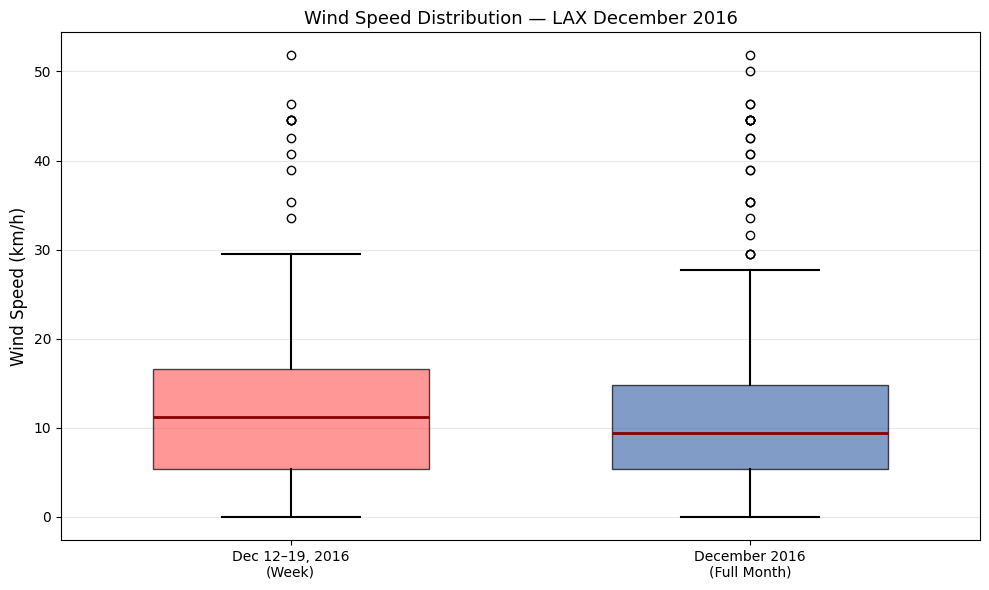

In [108]:
# LAX December 2016 — Box and Whisker Plot: Week vs Month

st_id = "72295"  # LAX
month_start = datetime(2016, 12, 1)
month_end = datetime(2016, 12, 31)
p1_start, p1_end = datetime(2016, 12, 12), datetime(2016, 12, 19)

# Fetch data for the full month
print("Fetching hourly data for LAX (Dec 2016)...")
ts_month = ms.hourly(st_id, month_start, month_end).fetch()
month_wspd = ts_month['wspd'].dropna()

# Fetch data for P1 week
print("Fetching hourly data for P1 week (Dec 12-19, 2016)...")
ts_week = ms.hourly(st_id, p1_start, p1_end).fetch()
week_wspd = ts_week['wspd'].dropna()

# Create box plot
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [week_wspd, month_wspd]
bp = ax.boxplot(data_to_plot, labels=['Dec 12–19, 2016\n(Week)', 'December 2016\n(Full Month)'],
                 patch_artist=True, widths=0.6)

# Customize colors
colors = ['#FF6B6B', '#4C72B0']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5)
for cap in bp['caps']:
    cap.set(linewidth=1.5)
for median in bp['medians']:
    median.set(color='darkred', linewidth=2)

ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
ax.set_title('Wind Speed Distribution — LAX December 2016', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)

# Add statistics
print(f"\nWeek (Dec 12-19):")
print(f"  Count: {len(week_wspd)}, Mean: {week_wspd.mean():.2f}, Median: {week_wspd.median():.2f}, Std: {week_wspd.std():.2f}")
print(f"\nMonth (December):")
print(f"  Count: {len(month_wspd)}, Mean: {month_wspd.mean():.2f}, Median: {month_wspd.median():.2f}, Std: {month_wspd.std():.2f}")

plt.tight_layout()
plt.show()

Fetching hourly data for LAX (Dec 2016 - Feb 2017)...
Fetching hourly data for P1 week (Dec 12-19, 2016)...

Week (Dec 12-19, 2016):
  Count: 169, Mean: 12.59, Median: 11.20, Std: 10.23

Winter (Dec 2016–Feb 2017):
  Count: 2137, Mean: 11.45, Median: 9.40, Std: 8.07


/var/folders/4m/_rb2pz1d7jx9ywsn916lhr_c0000gn/T/ipykernel_53840/4254781811.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Dec 12–19, 2016\n(Week)', 'Dec 2016–Feb 2017\n(Full Winter)'],


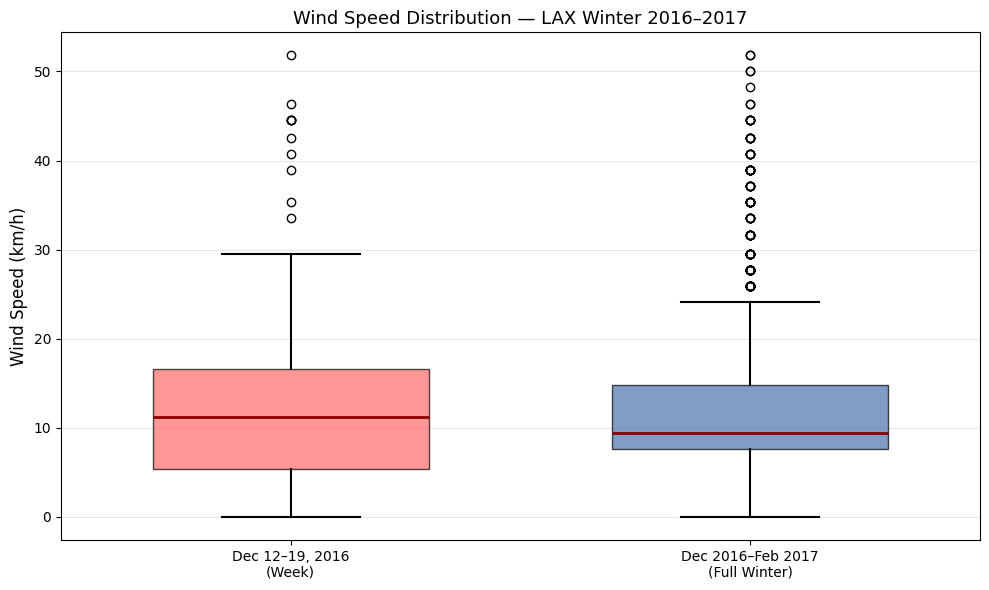

In [109]:
# LAX Winter 2016-2017 — Box and Whisker Plot: Week vs Full Winter

st_id = "72295"  # LAX
winter_start = datetime(2016, 12, 1)
winter_end = datetime(2017, 2, 28)
p1_start, p1_end = datetime(2016, 12, 12), datetime(2016, 12, 19)

# Fetch data for the full winter period (Dec 2016 - Feb 2017)
print("Fetching hourly data for LAX (Dec 2016 - Feb 2017)...")
ts_winter = ms.hourly(st_id, winter_start, winter_end).fetch()
winter_wspd = ts_winter['wspd'].dropna()

# Fetch data for P1 week
print("Fetching hourly data for P1 week (Dec 12-19, 2016)...")
ts_week = ms.hourly(st_id, p1_start, p1_end).fetch()
week_wspd = ts_week['wspd'].dropna()

# Create box plot
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [week_wspd, winter_wspd]
bp = ax.boxplot(data_to_plot, labels=['Dec 12–19, 2016\n(Week)', 'Dec 2016–Feb 2017\n(Full Winter)'],
                 patch_artist=True, widths=0.6)

# Customize colors
colors = ['#FF6B6B', '#4C72B0']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5)
for cap in bp['caps']:
    cap.set(linewidth=1.5)
for median in bp['medians']:
    median.set(color='darkred', linewidth=2)

ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
ax.set_title('Wind Speed Distribution — LAX Winter 2016–2017', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)

# Add statistics
print(f"\nWeek (Dec 12-19, 2016):")
print(f"  Count: {len(week_wspd)}, Mean: {week_wspd.mean():.2f}, Median: {week_wspd.median():.2f}, Std: {week_wspd.std():.2f}")
print(f"\nWinter (Dec 2016–Feb 2017):")
print(f"  Count: {len(winter_wspd)}, Mean: {winter_wspd.mean():.2f}, Median: {winter_wspd.median():.2f}, Std: {winter_wspd.std():.2f}")

plt.tight_layout()
plt.show()

Fetching hourly data for LAX (1995-2015)...
Fetching hourly data for P1 week (Dec 12-19, 2016)...

Week (Dec 12-19, 2016):
  Count: 169, Mean: 12.59, Median: 11.20, Std: 10.23

Winter (Dec 1995–Feb 2015):
  Count: 45335, Mean: 10.52, Median: 9.40, Std: 7.41


/var/folders/4m/_rb2pz1d7jx9ywsn916lhr_c0000gn/T/ipykernel_53840/2137705849.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Dec 12–19, 2016\n(Week)', 'Dec 1995–Feb 2015\n(Full Winter)'],


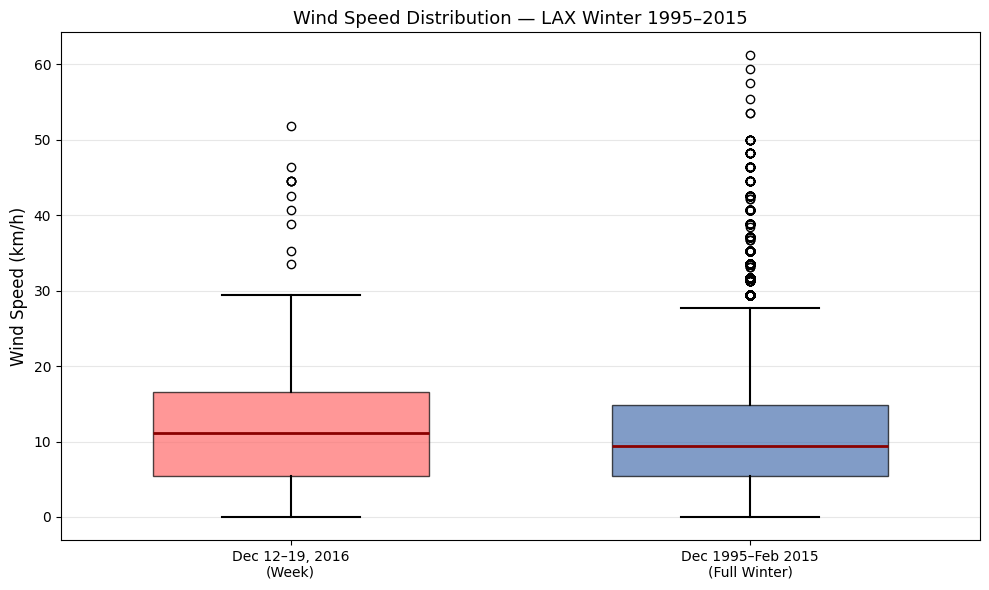

In [110]:
# LAX Winter — Box and Whisker Plot: Week vs Winters (1995-2015)

st_id = "72295"  # LAX
winter_start = datetime(1995, 12, 1)
winter_end = datetime(2015, 2, 28)
p1_start, p1_end = datetime(2016, 12, 12), datetime(2016, 12, 19)

# Fetch and prepare climatology data
print("Fetching hourly data for LAX (1995-2015)...")
ts = ms.hourly(st_id, start, end).fetch()
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()
winter_wspd = winter_data['wspd'].dropna()

# Fetch data for P1 week
print("Fetching hourly data for P1 week (Dec 12-19, 2016)...")
ts_week = ms.hourly(st_id, p1_start, p1_end).fetch()
week_wspd = ts_week['wspd'].dropna()

# Create box plot
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [week_wspd, winter_wspd]
bp = ax.boxplot(data_to_plot, labels=['Dec 12–19, 2016\n(Week)', 'Dec 1995–Feb 2015\n(Full Winter)'],
                 patch_artist=True, widths=0.6)

# Customize colors
colors = ['#FF6B6B', '#4C72B0']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5)
for cap in bp['caps']:
    cap.set(linewidth=1.5)
for median in bp['medians']:
    median.set(color='darkred', linewidth=2)

ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
ax.set_title('Wind Speed Distribution — LAX Winter 1995–2015', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)

# Add statistics
print(f"\nWeek (Dec 12-19, 2016):")
print(f"  Count: {len(week_wspd)}, Mean: {week_wspd.mean():.2f}, Median: {week_wspd.median():.2f}, Std: {week_wspd.std():.2f}")
print(f"\nWinter (Dec 1995–Feb 2015):")
print(f"  Count: {len(winter_wspd)}, Mean: {winter_wspd.mean():.2f}, Median: {winter_wspd.median():.2f}, Std: {winter_wspd.std():.2f}")

plt.tight_layout()
plt.show()

Fetching hourly data for LAX (1995-2015)...
Fetching hourly data for P1 week (Dec 12-19, 2016)...

Week (Dec 12-19, 2016):
  Count: 169, Mean: 14.18, Median: 15.00, Std: 2.55

Winter (Dec 1995–Feb 2015):
  Count: 45452, Mean: 13.97, Median: 13.90, Std: 3.50


/var/folders/4m/_rb2pz1d7jx9ywsn916lhr_c0000gn/T/ipykernel_53840/2626429823.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Dec 12–19, 2016\n(Week)', 'Dec 1995–Feb 2015\n(Full Winter)'],


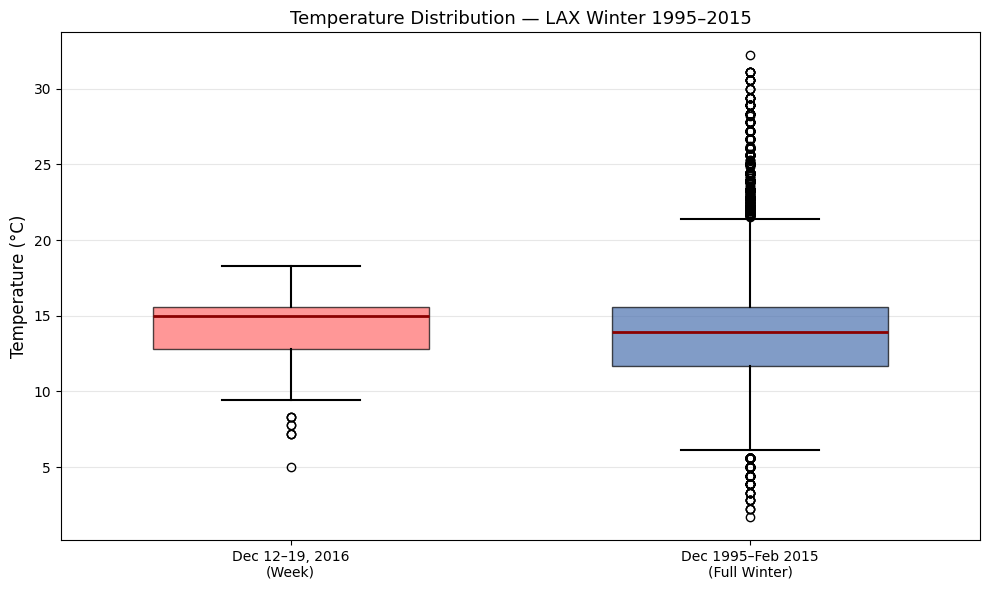

In [111]:
# LAX Winter — Box and Whisker Plot: Week vs Winters (1995-2015)

st_id = "72295"  # LAX
winter_start = datetime(1995, 12, 1)
winter_end = datetime(2015, 2, 28)
p1_start, p1_end = datetime(2016, 12, 12), datetime(2016, 12, 19)

# Fetch and prepare climatology data
print("Fetching hourly data for LAX (1995-2015)...")
ts = ms.hourly(st_id, start, end).fetch()
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()
winter_temp = winter_data['temp'].dropna()

# Fetch data for P1 week
print("Fetching hourly data for P1 week (Dec 12-19, 2016)...")
ts_week = ms.hourly(st_id, p1_start, p1_end).fetch()
week_temp = ts_week['temp'].dropna()

# Create box plot
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [week_temp, winter_temp]
bp = ax.boxplot(data_to_plot, labels=['Dec 12–19, 2016\n(Week)', 'Dec 1995–Feb 2015\n(Full Winter)'],
                 patch_artist=True, widths=0.6)

# Customize colors
colors = ['#FF6B6B', '#4C72B0']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5)
for cap in bp['caps']:
    cap.set(linewidth=1.5)
for median in bp['medians']:
    median.set(color='darkred', linewidth=2)

ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Temperature Distribution — LAX Winter 1995–2015', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)

# Add statistics
print(f"\nWeek (Dec 12-19, 2016):")
print(f"  Count: {len(week_temp)}, Mean: {week_temp.mean():.2f}, Median: {week_temp.median():.2f}, Std: {week_temp.std():.2f}")
print(f"\nWinter (Dec 1995–Feb 2015):")
print(f"  Count: {len(winter_temp)}, Mean: {winter_temp.mean():.2f}, Median: {winter_temp.median():.2f}, Std: {winter_temp.std():.2f}")

plt.tight_layout()
plt.show()

In [101]:
# Check raw wind speed distribution for a specific hour
st_id = "KHHR0"
start = datetime(1995, 1, 1)
end = datetime(2015, 12, 31)

ts = ms.hourly(st_id, start, end).fetch()
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()
winter_data['hour'] = winter_data.index.hour
winter_data_nonzero = winter_data[winter_data['wspd'] > 0].copy()

# Look at hour 12 (midday) as an example
hour_12_data = winter_data_nonzero[winter_data_nonzero['hour'] == 12]['wspd']

print("Hour 12 statistics:")
print(f"Unique values count: {hour_12_data.nunique()}")
print(f"Unique values (first 30): {sorted(hour_12_data.unique())[:30]}")
print(f"\nValue counts (top 20):")
print(hour_12_data.value_counts().head(20))

Hour 12 statistics:
Unique values count: 14
Unique values (first 30): [np.float64(5.4), np.float64(7.6), np.float64(9.4), np.float64(11.2), np.float64(13.0), np.float64(14.8), np.float64(16.6), np.float64(18.4), np.float64(20.5), np.float64(22.3), np.float64(24.1), np.float64(25.9), np.float64(31.7), np.float64(35.3)]

Value counts (top 20):
wspd
5.4     84
7.6     37
9.4     23
11.2    18
13.0    14
18.4     5
16.6     4
14.8     4
20.5     3
24.1     2
31.7     1
25.9     1
22.3     1
35.3     1
Name: count, dtype: Int64


Fetching hourly data for LAX (2010-2015)...
Fetching hourly data for P1 week (Dec 12-19, 2016)...


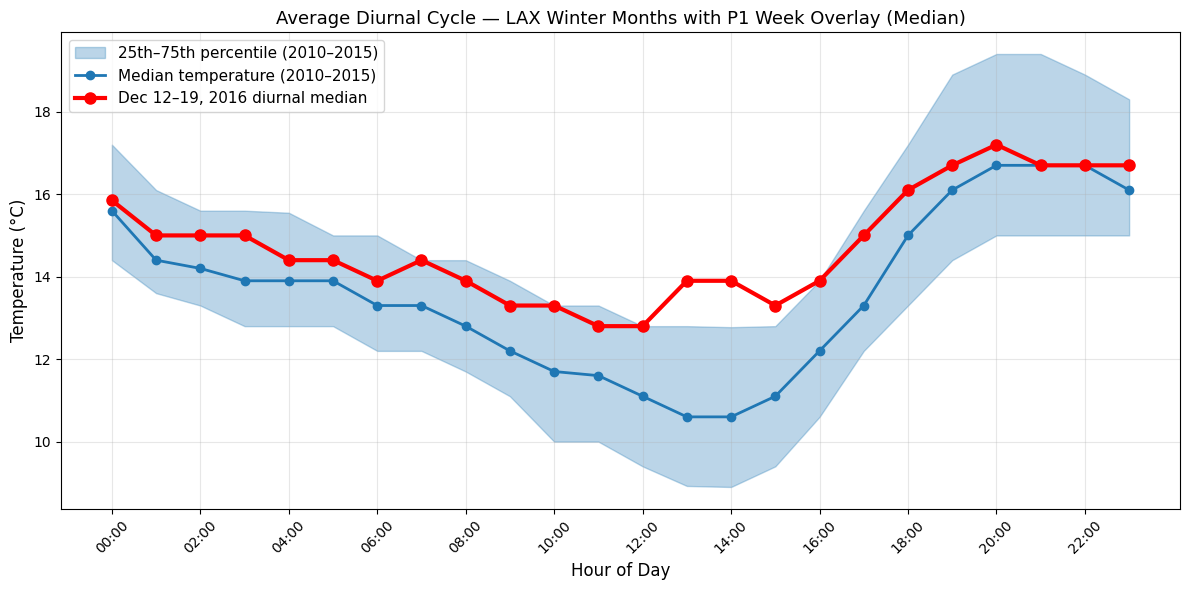

In [83]:
# LAX Climatology (2010-2015), Winter + P1 week overlay — Temperature (using median)

st_id = "72295"  # LAX
start = datetime(1995, 1, 1)
end = datetime(2015, 12, 31)
p1_start, p1_end = datetime(2016, 12, 12), datetime(2016, 12, 19)

# Fetch and prepare climatology data
print("Fetching hourly data for LAX (2010-2015)...")
ts = ms.hourly(st_id, start, end).fetch()
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()
winter_data['hour'] = winter_data.index.hour
hourly_cycle = winter_data.groupby('hour')['temp'].agg([
    'median',
    ('p25', lambda x: x.quantile(0.25)),
    ('p75', lambda x: x.quantile(0.75)),
]).reset_index()

# Fetch P1 week data
print("Fetching hourly data for P1 week (Dec 12-19, 2016)...")
ts_p1 = ms.hourly(st_id, p1_start, p1_end).fetch()
ts_p1['hour'] = ts_p1.index.hour
p1_hourly = ts_p1.groupby('hour')['temp'].median()

# Create combined plot
fig, ax = plt.subplots(figsize=(12, 6))

hours = hourly_cycle['hour'].values
median_temp = hourly_cycle['median'].values
p25 = hourly_cycle['p25'].values
p75 = hourly_cycle['p75'].values

# Climatology with shaded band
ax.fill_between(hours, p25, p75, alpha=0.3, color='C0', label='25th–75th percentile (2010–2015)')
ax.plot(hours, median_temp, 'o-', linewidth=2, markersize=6, 
        color='C0', label='Median temperature (2010–2015)')

# P1 week overlay
ax.plot(p1_hourly.index, p1_hourly.values, 'o-', linewidth=3, markersize=8, 
        color='red', label='Dec 12–19, 2016 diurnal median')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Average Diurnal Cycle — LAX Winter Months with P1 Week Overlay (Median)', fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Fetching hourly data for LAX (2010-2015)...
Fetching hourly data for P1 week (Dec 12-19, 2016)...


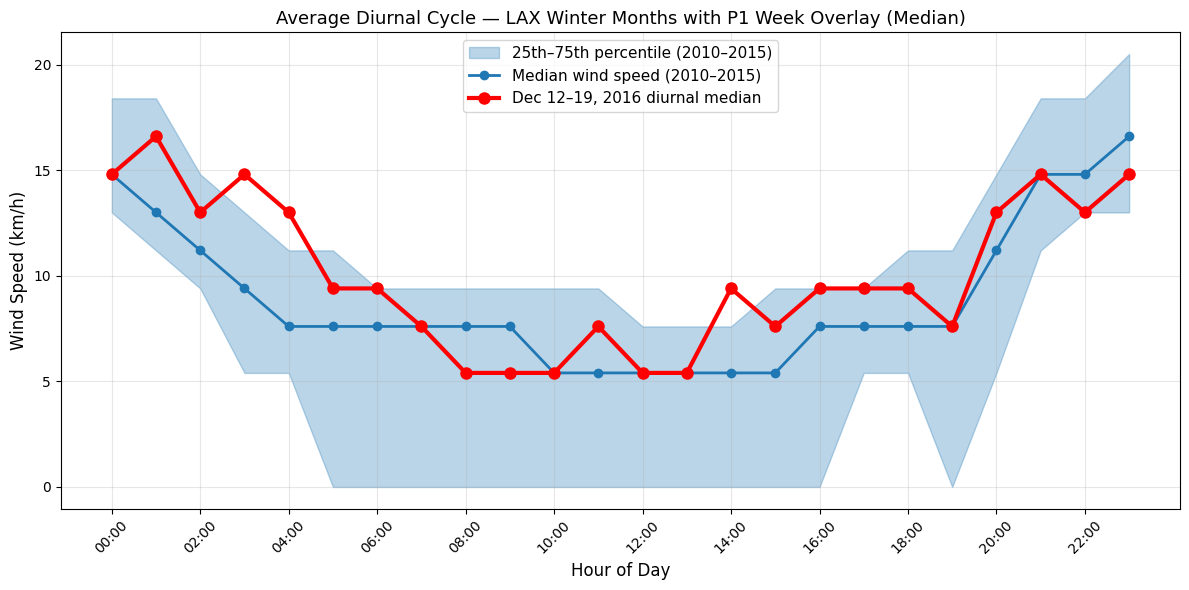

In [82]:
# LAX Climatology (2010-2015), Winter + P1 week overlay — Wind Speed (using median)

st_id = "72295"  # LAX
start = datetime(2010, 1, 1)
end = datetime(2015, 12, 31)
p1_start, p1_end = datetime(2016, 12, 12), datetime(2016, 12, 19)

# Fetch and prepare climatology data
print("Fetching hourly data for LAX (2010-2015)...")
ts = ms.hourly(st_id, start, end).fetch()
ts['month'] = ts.index.month
winter_data = ts[ts['month'].isin([12, 1, 2])].copy()
winter_data['hour'] = winter_data.index.hour
hourly_cycle = winter_data.groupby('hour')['wspd'].agg([
    'median',
    ('p25', lambda x: x.quantile(0.25)),
    ('p75', lambda x: x.quantile(0.75)),
]).reset_index()

# Fetch P1 week data
print("Fetching hourly data for P1 week (Dec 12-19, 2016)...")
ts_p1 = ms.hourly(st_id, p1_start, p1_end).fetch()
ts_p1['hour'] = ts_p1.index.hour
p1_hourly = ts_p1.groupby('hour')['wspd'].median()

# Create combined plot
fig, ax = plt.subplots(figsize=(12, 6))

hours = hourly_cycle['hour'].values
median_wspd = hourly_cycle['median'].values
p25 = hourly_cycle['p25'].values
p75 = hourly_cycle['p75'].values

# Climatology with shaded band
ax.fill_between(hours, p25, p75, alpha=0.3, color='C0', label='25th–75th percentile (2010–2015)')
ax.plot(hours, median_wspd, 'o-', linewidth=2, markersize=6, 
        color='C0', label='Median wind speed (2010–2015)')

# P1 week overlay
ax.plot(p1_hourly.index, p1_hourly.values, 'o-', linewidth=3, markersize=8, 
        color='red', label='Dec 12–19, 2016 diurnal median')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Wind Speed (km/h)', fontsize=12)
ax.set_title('Average Diurnal Cycle — LAX Winter Months with P1 Week Overlay (Median)', fontsize=13)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [62]:
st_id = "KHHR0"
p1_start = datetime(2016, 12, 12)
p1_end = datetime(2016, 12, 19)

# 1) Get daily data — ms.daily() returns a TimeSeries builder
ts = ms.daily(st_id, p1_start, p1_end)

# 2) Call .fetch() to get the actual DataFrame
df = ts.fetch()

# 3) Now you can subscript and work with the DataFrame
if df is not None and not df.empty:
    print("Got data:")
    print(df[['temp', 'wspd']].mean())
else:
    print("No data returned — check station ID and date range.")

Got data:
temp    14.1125
wspd     6.4375
dtype: Float64


In [64]:
station = ms.Station(id=st_id)
ts = ms.daily(station, p1_start, p1_end)
df = ts.fetch()
df

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2016-12-12,16.2,15.0,18.3,84,0.0,<NA>,5.4,<NA>,1018.8,<NA>,<NA>
2016-12-13,15.7,13.9,17.8,81,0.0,<NA>,3.9,<NA>,1019.2,<NA>,<NA>
2016-12-14,15.0,11.7,20.0,84,0.0,<NA>,3.7,<NA>,1018.3,<NA>,0
2016-12-15,14.5,12.8,17.2,92,<NA>,<NA>,5.4,<NA>,1015.7,<NA>,<NA>
2016-12-16,14.6,11.7,16.7,75,<NA>,<NA>,22.6,<NA>,1011.4,<NA>,<NA>
2016-12-17,11.8,9.4,15.6,43,0.0,<NA>,6.0,<NA>,1019.6,<NA>,0
2016-12-18,11.7,6.1,18.9,37,0.0,<NA>,2.1,<NA>,1021.8,<NA>,0
2016-12-19,13.4,5.6,22.2,26,0.0,<NA>,2.4,<NA>,1023.2,<NA>,0


In [27]:
# Helper: fetch daily and return mean for window
def weekly_mean(station_id, start, end):
    df = ms.daily(station_id, start, end)
    return df[['tavg','wspd']].mean()

week1 = weekly_mean(st_id, p1_start, p1_end)
week2 = weekly_mean(st_id, p2_start, p2_end)

# 3) Build climatology (30-year period; change years as desired)
clim_years = range(1991, 2021)  # 1991-2020
def climatology_stats(station_id, start, end, years):
    rows = []
    for y in years:
        s = start.replace(year=y)
        e = end.replace(year=y)
        df = ms.daily(station_id, s, e).fetch()[['tavg','wspd']]
        if df.empty or df.isnull().all().all():
            continue
        rows.append(df.mean())
    clim = pd.DataFrame(rows)
    return clim.mean(), clim.quantile(0.25), clim.quantile(0.75)

clim1_mean, clim1_p25, clim1_p75 = climatology_stats(st_id, p1_start, p1_end, clim_years)
clim2_mean, clim2_p25, clim2_p75 = climatology_stats(st_id, p2_start, p2_end, clim_years)

TypeError: 'TimeSeries' object is not subscriptable

In [ ]:
# 4) Plot: two panels (Dec & Aug), two variables (temperature, wind speed)
vars = ['tavg','wspd']
labels = ['Temperature (°C)','Wind speed (km/h)']  # convert if you prefer other units
fig, axes = plt.subplots(1,2, figsize=(12,5))

for ax, week, clim_mean, clim_p25, clim_p75, title in [
    (axes[0], week1, clim1_mean, clim1_p25, clim1_p75, 'Dec 12–19, 2016'),
    (axes[1], week2, clim2_mean, clim2_p25, clim2_p75, 'Aug 12–19, 2016'),
]:
    x = np.arange(len(vars))
    clim_vals = clim_mean[vars].values
    lower = (clim_mean - clim_p25)[vars].values
    upper = (clim_p75 - clim_mean)[vars].values

    ax.bar(x-0.15, clim_vals, width=0.3, label='Climatology mean', color='C0')
    ax.errorbar(x-0.15, clim_vals, yerr=[lower, upper], fmt='none', ecolor='k', capsize=6)
    ax.bar(x+0.15, week[vars].values, width=0.3, label='2016 weekly mean', color='C1')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()